In [11]:
# Geographic Concentration of Transactions

## 1. Data Loading & Validation
## 2. Data Cleaning & Preparation
## 3. Transformation to Country-Level Dataset
## 4. Concentration Analysis
## 5. Visualization (Pareto)
## 6. Business Interpretation

## 1. Data Loading & Validation


This section loads the raw ECB PAY dataset and performs basic validation
checks to understand the structure, coverage, and suitability of the data
for geographic concentration analysis.

The raw dataset is kept unmodified to preserve data lineage and
reproducibility

In [12]:
import pandas as pd

# Path to raw ECB dataset
path = "../data/raw/ECB Data Portal_20260417154512.csv"

df = pd.read_csv(path)
df.head()

#df.info()

,DATE,TIME PERIOD,"Total payment transactions, sent (PAY.A.AT.W0.TOTL1.1._Z.N.PN)","Total payment transactions, sent (PAY.A.BE.W0.TOTL1.1._Z.N.PN)","Total payment transactions, sent (PAY.A.BG.W0.TOTL1.1._Z.N.PN)","Total payment transactions, sent (PAY.A.CY.W0.TOTL1.1._Z.N.PN)","Total payment transactions, sent (PAY.A.CZ.W0.TOTL1.1._Z.N.PN)","Total payment transactions, sent (PAY.A.DE.W0.TOTL1.1._Z.N.PN)","Total payment transactions, sent (PAY.A.DK.W0.TOTL1.1._Z.N.PN)","Total payment transactions, sent (PAY.A.EE.W0.TOTL1.1._Z.N.PN)",...,"Total payment transactions, sent (PAY.A.LU.W0.TOTL1.1._Z.N.PN)","Total payment transactions, sent (PAY.A.LV.W0.TOTL1.1._Z.N.PN)","Total payment transactions, sent (PAY.A.MT.W0.TOTL1.1._Z.N.PN)","Total payment transactions, sent (PAY.A.NL.W0.TOTL1.1._Z.N.PN)","Total payment transactions, sent (PAY.A.PL.W0.TOTL1.1._Z.N.PN)","Total payment transactions, sent (PAY.A.PT.W0.TOTL1.1._Z.N.PN)","Total payment transactions, sent (PAY.A.RO.W0.TOTL1.1._Z.N.PN)","Total payment transactions, sent (PAY.A.SE.W0.TOTL1.1._Z.N.PN)","Total payment transactions, sent (PAY.A.SI.W0.TOTL1.1._Z.N.PN)","Total payment transactions, sent (PAY.A.SK.W0.TOTL1.1._Z.N.PN)"
0,2000-12-31,2000,887.580,1390.743,19.311,37.46,564.30,12209.047,823.99,49.101,...,NaN,58.911,13.410,2894.369,490.416,982.860,52.844,1212.90,NaN,NaN
1,2001-12-31,2001,955.240,1542.614,24.493,41.80,920.10,12520.973,869.98,67.379,...,43.515,64.957,14.470,3140.885,606.931,1072.083,65.384,1266.50,NaN,NaN
2,2002-12-31,2002,1012.990,1703.845,26.269,46.51,754.30,12156.759,928.29,86.220,...,50.585,75.768,16.800,3408.805,632.032,1154.187,81.334,1147.70,NaN,NaN
3,2003-12-31,2003,1746.300,1668.717,32.764,49.32,669.10,13432.104,1004.03,106.591,...,53.344,89.574,21.100,3582.460,781.524,1253.369,113.718,1432.77,NaN,155.536
4,2004-12-31,2004,1770.251,1797.116,42.429,57.89,775.78,14612.482,1087.62,134.518,...,56.539,107.546,21.108,3738.386,935.977,1303.152,166.064,1669.00,286.485,171.998


## 2. Data Cleaning & Preparation

The dataset is provided in a wide format, with:
- One column per reporting country
- Annual observations
- Transaction volumes expressed as *pure counts* (PN – Pure Number)

Since the objective of this analysis is to assess geographic concentration,
only transaction *levels* are required. The dataset already excludes growth
rates, so no additional filtering between levels and rates is necessary.

The preparation step therefore focuses on:
- Identifying country-level transaction columns
- Ensuring numerical consistency
- Preparing the dataset for transformation to a long format

In [13]:
# Identify country-level transaction columns
value_cols = [
    c for c in df.columns
    if "Total payment transactions, sent" in c
]

len(value_cols), value_cols[:5]

(26,
 ['Total payment transactions, sent (PAY.A.AT.W0.TOTL1.1._Z.N.PN)',
  'Total payment transactions, sent (PAY.A.BE.W0.TOTL1.1._Z.N.PN)',
  'Total payment transactions, sent (PAY.A.BG.W0.TOTL1.1._Z.N.PN)',
  'Total payment transactions, sent (PAY.A.CY.W0.TOTL1.1._Z.N.PN)',
  'Total payment transactions, sent (PAY.A.CZ.W0.TOTL1.1._Z.N.PN)'])

## 3. Transformation to Country-Level Dataset

The data is transformed from wide to long format to obtain a clean
country-level dataset with the following structure:

- Year
- Country
- Number of transactions

This format simplifies aggregation, comparison, and visualization.

In [14]:
base_df = df[["TIME PERIOD"] + value_cols].copy()

long_df = base_df.melt(
    id_vars="TIME PERIOD",
    var_name="series",
    value_name="transactions"
)

# Extract country code from ECB series identifier
long_df["country"] = long_df["series"].str.extract(r"PAY\.A\.([A-Z]{2})\.")

# Convert transactions to numeric
long_df["transactions"] = pd.to_numeric(long_df["transactions"], errors="coerce")

# Remove missing values
long_df = long_df.dropna(subset=["country", "transactions"])

long_df.head()

,TIME PERIOD,series,transactions,country
0,2000,"Total payment transactions, sent (PAY.A.AT.W0....",887.580,AT
1,2001,"Total payment transactions, sent (PAY.A.AT.W0....",955.240,AT
2,2002,"Total payment transactions, sent (PAY.A.AT.W0....",1012.990,AT
3,2003,"Total payment transactions, sent (PAY.A.AT.W0....",1746.300,AT
4,2004,"Total payment transactions, sent (PAY.A.AT.W0....",1770.251,AT


## 4. Concentration Analysis

Geographic concentration is assessed by calculating each country's
share of total transactions for a selected year.

The cumulative share is used to identify concentration patterns
(Pareto-style analysis).

In [15]:
year = "2024"

df_year = (
    long_df[long_df["TIME PERIOD"].astype(str) == year]
    .groupby("country", as_index=False)["transactions"]
    .sum()
)

df_year["share"] = df_year["transactions"] / df_year["transactions"].sum()
df_year = df_year.sort_values("share", ascending=False)
df_year["share_cum"] = df_year["share"].cumsum()

df_year.head(10)

,country,transactions,share,share_cum
9,FR,32548.631,0.201927,0.201927
5,DE,30509.051,0.189273,0.391200
7,ES,17399.807,0.107946,0.499146
18,PL,16090.905,0.099825,0.598971
13,IT,14783.474,0.091714,0.690686
1,BE,6759.569,0.041935,0.732621
15,LU,5669.075,0.035170,0.767791
12,IE,4697.514,0.029143,0.796934
4,CZ,4663.285,0.028930,0.825864
14,LT,4248.864,0.026359,0.852223


### Saving processed data

The aggregated country-level dataset is stored separately from the raw data
to preserve data lineage, ensure reproducibility, and improve reusability
for reporting and visualization purposes.

In [16]:
# Ensure output directory exists
import os

processed_path = "../data/processed"
os.makedirs(processed_path, exist_ok=True)

# Save processed dataset
output_file = f"{processed_path}/transactions_by_country_{year}.csv"
df_year.to_csv(output_file, index=False)

output_file

'../data/processed/transactions_by_country_2024.csv'

## 5. Visualization (Pareto)

A Pareto-style chart is used to visualize geographic concentration:

- Bars represent each country's share of total transactions
- The cumulative line highlights how quickly transaction volume
  concentrates across a small number of countries

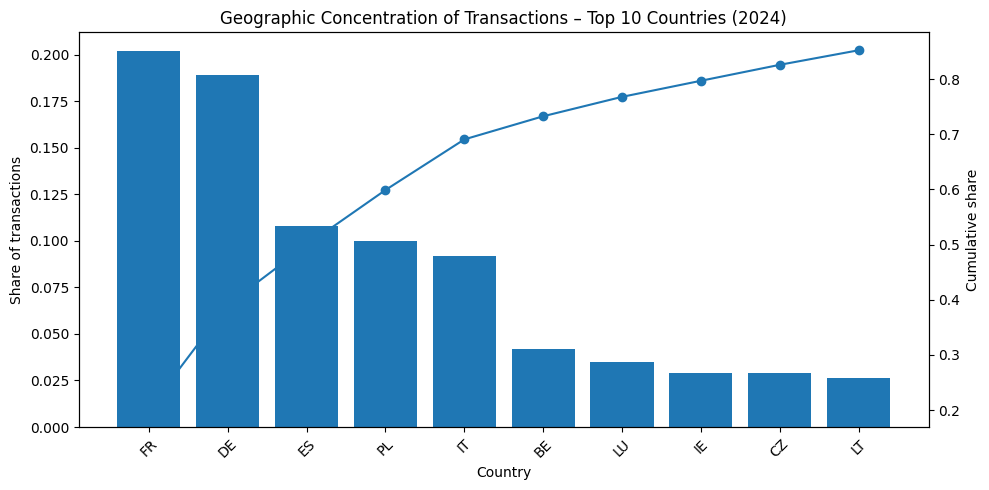

In [25]:
import matplotlib.pyplot as plt

top_n = 10
plot_df = df_year.head(top_n)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(plot_df["country"], plot_df["share"])
ax1.set_ylabel("Share of transactions")
ax1.set_xlabel("Country")
ax1.set_title(f"Geographic Concentration of Transactions – Top {top_n} Countries ({year})")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(plot_df["country"], plot_df["share_cum"], marker="o")
ax2.set_ylabel("Cumulative share")

plt.tight_layout()



### Saving figures

The Pareto chart is exported as a static image to allow reuse in reports,
presentations, and the project README.

In [18]:
figures_path = "../figures"
os.makedirs(figures_path, exist_ok=True)

figure_file = f"{figures_path}/pareto_geographic_concentration_{year}.png"

fig.savefig(figure_file, dpi=300, bbox_inches="tight")  
plt.show()

### 6. Transaction Trends

This analysis focuses on the geographic evolution of transactions. The top 10 countries by transaction share are visualized to examine how transaction volumes evolve over time.

In [20]:
#Define the top 10 countries for the reference year

year_ref = 2024

top10_countries = (
    long_df[long_df["TIME PERIOD"] == year_ref]
    .groupby("country")["transactions"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

top10_countries


['FR', 'DE', 'ES', 'PL', 'IT', 'BE', 'LU', 'IE', 'CZ', 'LT']

In [21]:

evolution = (
    long_df[long_df["country"].isin(top10_countries)]
    .groupby(["TIME PERIOD", "country"], as_index=False)["transactions"]
    .sum()
    .sort_values(["country", "TIME PERIOD"])
)

evolution.head(20)


,TIME PERIOD,country,transactions
0,2000,BE,1390.743
9,2001,BE,1542.614
19,2002,BE,1703.845
29,2003,BE,1668.717
39,2004,BE,1797.116
49,2005,BE,1892.067
58,2006,BE,1978.946
67,2007,BE,2099.706
76,2008,BE,2197.820
85,2009,BE,2289.540


## 7. Visualization (Trend)

A trend-style chart is used to illustrate the geographic evolution of transaction volumes over time.




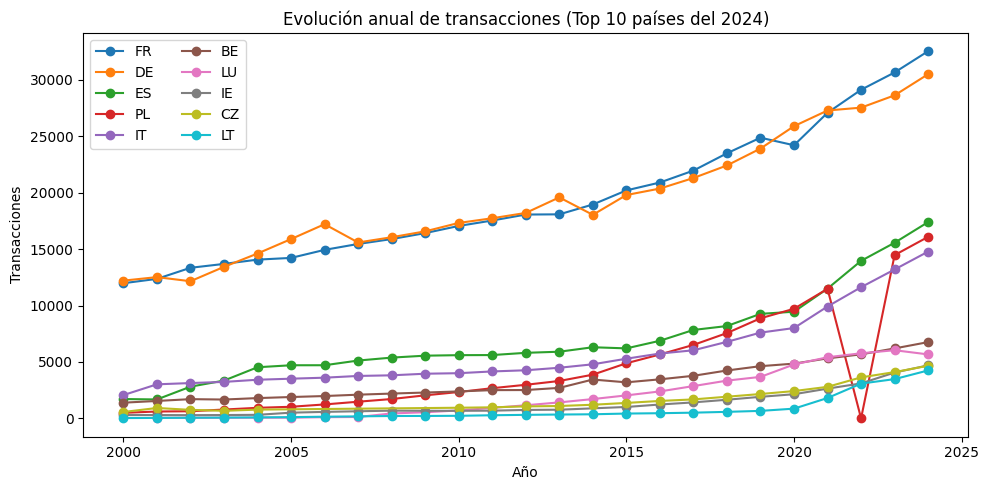

In [27]:

fig_trend, ax = plt.subplots(figsize=(10, 5))
for c in top10_countries:
    tmp = evolution[evolution["country"] == c]
    plt.plot(tmp["TIME PERIOD"], tmp["transactions"], marker="o", label=c)

plt.title(f"Evolución anual de transacciones (Top 10 países del {year_ref})")
plt.xlabel("Año")
plt.ylabel("Transacciones")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


### Saving figures

The trend chart is exported as a static image to allow reuse in reports,
presentations, and the project README.

In [29]:

figures_path = "../figures"
os.makedirs(figures_path, exist_ok=True)
fig_trend.savefig(f"{figures_path}/trend_geographic_concentration.png", dpi=300, bbox_inches="tight")
plt.show()
